In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('netflix_titles.csv')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()

Shape: (8807, 12)

Data types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate rows: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("Release year range:", df['release_year'].min(), "to", df['release_year'].max())

Duplicate rows: 0
Release year range: 1925 to 2021


This dataset contains 8,807 rows and 12 columns describing Netflix titles (movies and TV shows). It includes information such as title, type, director, cast, country, release year, rating, duration, and genre. There are missing values in columns like director (2,634), cast (825), and country (831), along with smaller gaps in date_added, rating, and duration. There are no duplicate rows. The data covers titles released from 1925 to 2021.

In [5]:
# Strip any leading/trailing whitespace from date strings before converting
df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print("Missing date_added after fix:", df['date_added'].isnull().sum())
# Drop duplicates (none here, but good practice to include)
df = df.drop_duplicates()

# Fill missing categorical values instead of dropping (we don't want to lose rows)
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows where rating or date_added is missing (small number, safe to drop)
df = df.dropna(subset=['rating', 'date_added'])

# Fix date type
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year added as its own column (useful for charts later)
df['year_added'] = df['date_added'].dt.year

print("Shape after cleaning:", df.shape)
print("Remaining missing values:\n", df.isnull().sum())

Missing date_added after fix: 88
Shape after cleaning: (8705, 13)
Remaining missing values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
dtype: int64


In [6]:
df['duration'] = df['duration'].fillna('Unknown')
print("Duration missing now:", df['duration'].isnull().sum())

Duration missing now: 0


I filled missing director, cast, country, and duration values with "Unknown" rather than dropping rows, since those columns aren't critical to most analysis and dropping them would lose too much data. I dropped rows missing rating (none, after checking) or with an unparseable date_added (88 rows had inconsistent date formatting that couldn't be converted), since these are a small fraction of the data and important for time-based analysis. I converted date_added to a proper datetime type and extracted the year into a new year_added column. Final cleaned dataset: 8,705 rows, 0 missing values.

In [20]:
df['rating'] = df['rating'].replace({
    '74 min': 'NR',
    '84 min': 'NR',
    '66 min': 'NR'
})

"A few records contained duration values ('74 min', '84 min', '66 min') in the rating column due to missing rating information. These records were cleaned before analysis."

In [7]:
print(df['type'].value_counts())

type
Movie      6129
TV Show    2576
Name: count, dtype: int64


In [8]:
print(df['country'].value_counts().head(10))

country
United States     2778
India              971
Unknown            826
United Kingdom     403
Japan              240
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64


In [9]:
print(df['rating'].value_counts().head(10))

rating
TV-MA    3183
TV-14    2133
TV-PG     838
R         799
PG-13     490
TV-Y7     330
TV-Y      300
PG        287
TV-G      212
NR         78
Name: count, dtype: int64


In [10]:
print(df['year_added'].value_counts().sort_index())

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     417
2017    1162
2018    1624
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64


In [11]:
all_genres = df['listed_in'].str.split(', ').explode()
print(all_genres.value_counts().head(10))

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1327
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

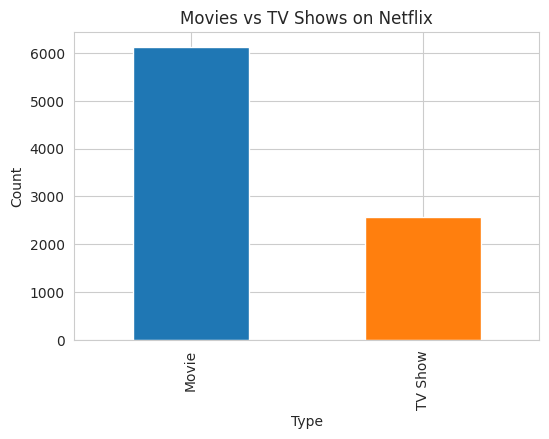

In [13]:
# 1. Bar chart — Movies vs TV Shows
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['#1f77b4','#ff7f0e'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

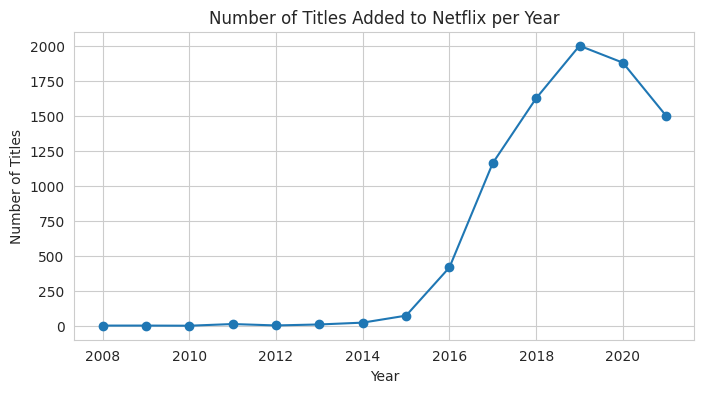

In [14]:
# 2. Line chart — Titles added per year
plt.figure(figsize=(8,4))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Number of Titles Added to Netflix per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

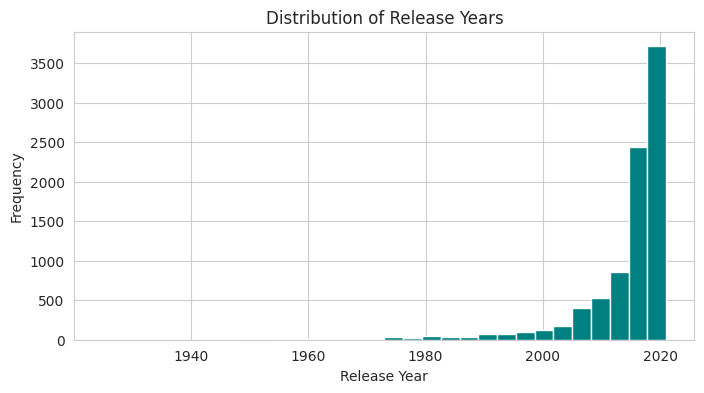

In [15]:
# 3. Histogram — Release year distribution
plt.figure(figsize=(8,4))
df['release_year'].plot(kind='hist', bins=30, color='teal')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

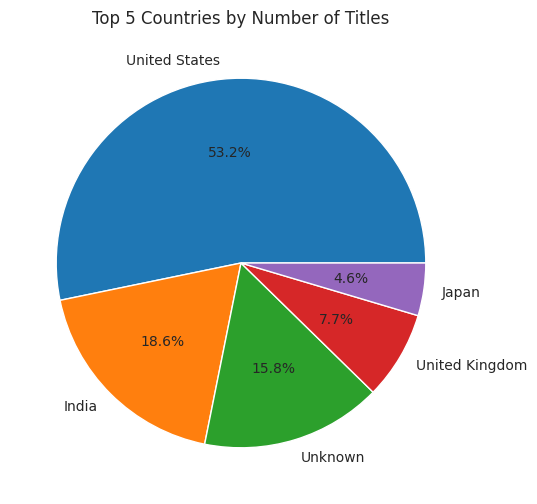

In [16]:
# 4. Pie chart — Top 5 countries
top_countries = df['country'].value_counts().head(5)
plt.figure(figsize=(6,6))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%')
plt.title('Top 5 Countries by Number of Titles')
plt.show()

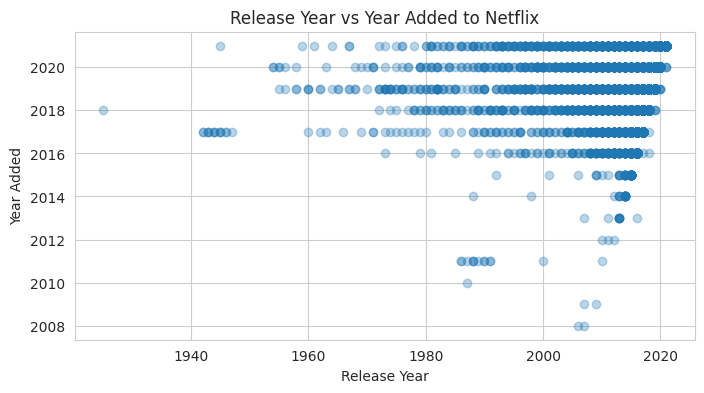

In [17]:
# 5. Scatter plot — Release year vs Year added
plt.figure(figsize=(8,4))
plt.scatter(df['release_year'], df['year_added'], alpha=0.3)
plt.title('Release Year vs Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added')
plt.show()

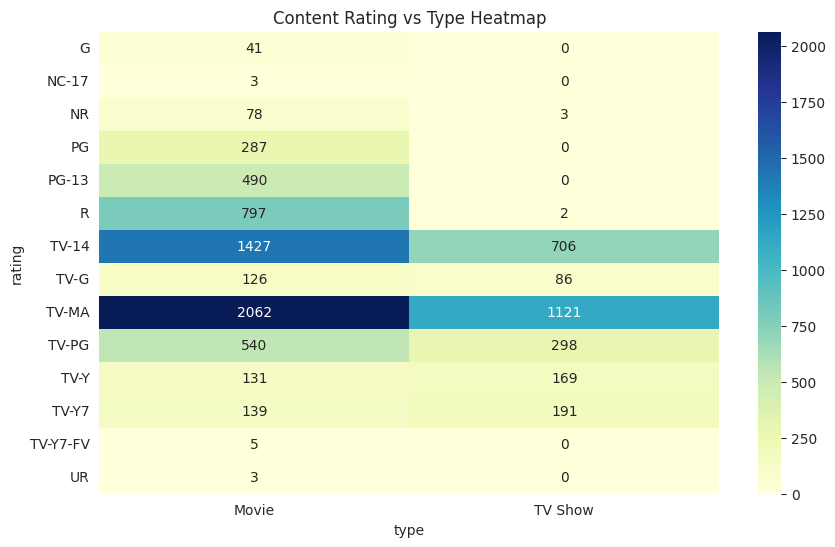

In [21]:
# 6. Heatmap — Content rating vs Type
plt.figure(figsize=(10,6))
pivot = pd.crosstab(df['rating'], df['type'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Content Rating vs Type Heatmap')
plt.show()

# Insights Report

- Netflix has significantly more Movies than TV Shows.
- The number of titles added to Netflix increased rapidly after 2015.
- Most Netflix content was released between 2015 and 2021.
- The United States contributes the largest share of Netflix titles.
- TV-MA is the most common content rating for both Movies and TV Shows.

# Finding That Surprised Me Most

The most surprising finding was that TV-MA is the most common content rating on Netflix. I expected family-friendly content to have the highest number of titles. However, the analysis showed that Netflix contains a large amount of content targeted toward mature audiences. This indicates that Netflix focuses heavily on adult viewers compared to children and family audiences.